Parámetros ajustados (sigma, rho, beta): [11.531  18.7833  1.7323]
Incertidumbre (1 sigma): [1.7058 0.9914 0.0953]
----- ANÁLISIS DE ERROR -----
Error cuadrático medio (MSE): 53.6233
Error absoluto medio (MAE): 5.5533
Ruido inyectado (std): 0.8


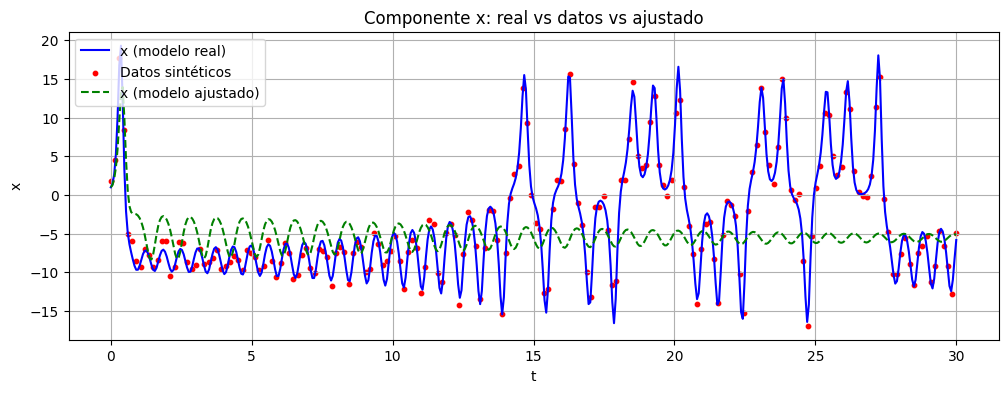

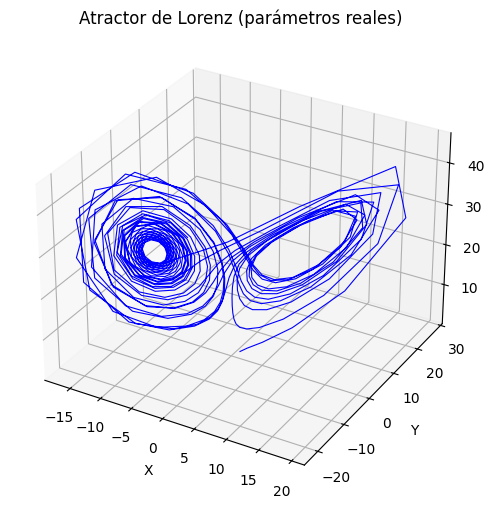

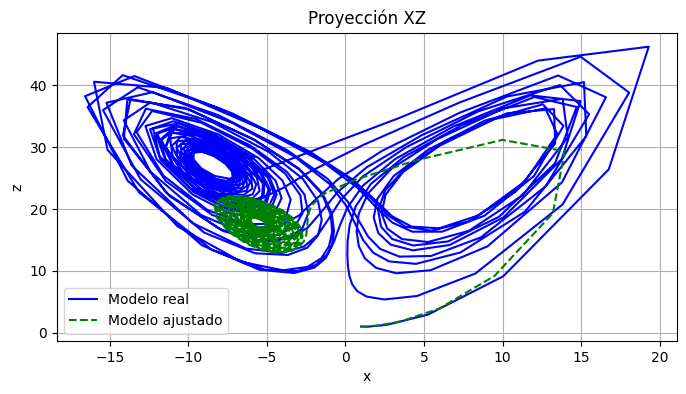

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from abc import ABC, abstractmethod
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. CLASE BASE ABSTRACTA
# ------------------------------------------------------------
class SistemaFisico(ABC):
    @abstractmethod
    def derivada(self, t, estado):
        """Retorna [dx/dt, dy/dt, dvx/dt, dvy/dt]"""
        pass

    @abstractmethod
    def simular(self, t_span, estado_inicial, t_eval=None):
        """Resuelve la EDO y retorna (t, solucion) con solucion.shape = (4, N)"""
        pass

# ------------------------------------------------------------
# 2. CLASE TERRENO (superficie o potencial)
# ------------------------------------------------------------
class Terreno:
    def __init__(self, funcion_altura, gradiente_func=None):
        self.altura = funcion_altura  # z(x,y) o energía potencial por unidad de masa
        if gradiente_func is None:
            self.gradiente = self._gradiente_numerico
        else:
            self.gradiente = gradiente_func

    def _gradiente_numerico(self, x, y, h=1e-5):
        dzdx = (self.altura(x+h, y) - self.altura(x-h, y)) / (2*h)
        dzdy = (self.altura(x, y+h) - self.altura(x, y-h)) / (2*h)
        return dzdx, dzdy

    def energia_potencial(self, x, y, masa, g):
        return masa * g * self.altura(x, y)

# ------------------------------------------------------------
# 3. CLASE PARTICULA (hereda de SistemaFisico)
# ------------------------------------------------------------
class Particula(SistemaFisico):
    def __init__(self, terreno, masa=1.0, rozamiento=0.1, gravedad=9.8):
        self.terreno = terreno
        self.masa = masa
        self.rozamiento = rozamiento   # coeficiente μ (fuerza = -μ * v)
        self.gravedad = gravedad

    def derivada(self, t, estado):
        x, y, vx, vy = estado
        dzdx, dzdy = self.terreno.gradiente(x, y)
        ax = -self.gravedad * dzdx - self.rozamiento * vx
        ay = -self.gravedad * dzdy - self.rozamiento * vy
        return [vx, vy, ax, ay]

    def simular(self, t_span, estado_inicial, t_eval=None):
        sol = solve_ivp(self.derivada, t_span, estado_inicial,
                        t_eval=t_eval, method='RK45', rtol=1e-6)
        return sol.t, sol.y

    def energia_cinetica(self, estado):
        _, _, vx, vy = estado
        return 0.5 * self.masa * (vx**2 + vy**2)

    def energia_potencial(self, estado):
        x, y, _, _ = estado
        return self.terreno.energia_potencial(x, y, self.masa, self.gravedad)

    def energia_total(self, estado):
        return self.energia_cinetica(estado) + self.energia_potencial(estado)

# ------------------------------------------------------------
# 4. CLASE ANALIZADOR (datos sintéticos, ajuste, gráficas)
# ------------------------------------------------------------
class Analizador:
    def __init__(self, modelo_real, estado_inicial, t_max, n_puntos, ruido_std=0.05):
        self.modelo = modelo_real
        self.estado0 = np.array(estado_inicial)
        self.t_max = t_max
        self.n_puntos = n_puntos
        self.ruido_std = ruido_std
        self.t_med = np.linspace(0, t_max, n_puntos)

        # Simulación real (sin ruido)
        _, self.y_real = self.modelo.simular((0, t_max), self.estado0, t_eval=self.t_med)

        # Añadir ruido a las posiciones (x,y)
        ruido_x = np.random.normal(0, ruido_std, size=self.t_med.shape)
        ruido_y = np.random.normal(0, ruido_std, size=self.t_med.shape)
        self.x_med = self.y_real[0] + ruido_x
        self.y_med = self.y_real[1] + ruido_y

        self.param_ajustados = None
        self.covarianza = None

    def modelo_para_ajuste(self, t, rozamiento, gravedad):
        """Devuelve x(t) e y(t) concatenados para curve_fit."""
        modelo_temp = Particula(self.modelo.terreno,
                                masa=self.modelo.masa,
                                rozamiento=rozamiento,
                                gravedad=gravedad)
        _, y_sim = modelo_temp.simular((0, self.t_max), self.estado0, t_eval=t)
        return np.concatenate([y_sim[0], y_sim[1]])

    def ajustar_parametros(self, p0=[0.2, 9.8]):
        """Ajusta rozamiento y gravedad usando curve_fit."""
        ydata = np.concatenate([self.x_med, self.y_med])
        popt, pcov = curve_fit(self.modelo_para_ajuste, self.t_med, ydata,
                               p0=p0, maxfev=5000)
        self.param_ajustados = popt
        self.covarianza = pcov
        return popt, pcov

    def errores(self):
        if self.param_ajustados is None:
            self.ajustar_parametros()
        roz_aj, g_aj = self.param_ajustados
        modelo_aj = Particula(self.modelo.terreno, self.modelo.masa, roz_aj, g_aj)
        _, y_aj = modelo_aj.simular((0, self.t_max), self.estado0, t_eval=self.t_med)
        error_x = self.x_med - y_aj[0]
        error_y = self.y_med - y_aj[1]
        mse = np.mean(error_x**2 + error_y**2)
        mae = np.mean(np.abs(error_x) + np.abs(error_y))
        print("----- ANÁLISIS DE ERROR -----")
        print(f"MSE posicional: {mse:.6f}")
        print(f"MAE posicional: {mae:.6f}")
        return error_x, error_y

    def graficar(self):
        if self.param_ajustados is None:
            self.ajustar_parametros()
        roz_aj, g_aj = self.param_ajustados
        modelo_aj = Particula(self.modelo.terreno, self.modelo.masa, roz_aj, g_aj)

        t_denso = np.linspace(0, self.t_max, 500)
        _, y_real_denso = self.modelo.simular((0, self.t_max), self.estado0, t_eval=t_denso)
        _, y_aj_denso = modelo_aj.simular((0, self.t_max), self.estado0, t_eval=t_denso)

        # Figura 1: Trayectorias en XY
        plt.figure(figsize=(10, 5))
        plt.plot(y_real_denso[0], y_real_denso[1], 'b-', label='Real (sin ruido)')
        plt.scatter(self.x_med, self.y_med, c='red', s=10, label='Datos con ruido')
        plt.plot(y_aj_denso[0], y_aj_denso[1], 'g--', label='Ajustado')
        plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.axis('equal'); plt.grid()
        plt.title('Trayectorias comparativas')
        plt.show()

        # Figura 2: Energías (modelo real)
        Ec = [0.5*self.modelo.masa*(vx**2+vy**2) for vx,vy in zip(y_real_denso[2], y_real_denso[3])]
        Ep = [self.modelo.terreno.energia_potencial(x,y,self.modelo.masa,self.modelo.gravedad)
              for x,y in zip(y_real_denso[0], y_real_denso[1])]
        Etot = np.array(Ec)+np.array(Ep)
        plt.figure(figsize=(10,4))
        plt.plot(t_denso, Ec, label='Cinética')
        plt.plot(t_denso, Ep, label='Potencial')
        plt.plot(t_denso, Etot, label='Total')
        plt.xlabel('t'); plt.ylabel('Energía'); plt.legend(); plt.grid()
        plt.title('Evolución de energías (modelo real)')
        plt.show()

        # Figura 3: Superficie 3D + trayectoria
        xg = np.linspace(-3,3,50); yg = np.linspace(-3,3,50); X,Y = np.meshgrid(xg,yg)
        Z = self.modelo.terreno.altura(X,Y)
        fig = plt.figure(figsize=(10,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(X, Y, Z, alpha=0.6, cmap='terrain')
        z_traj = [self.modelo.terreno.altura(x,y) for x,y in zip(y_real_denso[0], y_real_denso[1])]
        ax.plot(y_real_denso[0], y_real_denso[1], z_traj, 'r-', linewidth=2)
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
        ax.set_title('Superficie y trayectoria real')
        plt.show()

# ------------------------------------------------------------
# 5. PROGRAMA PRINCIPAL
# ------------------------------------------------------------
if __name__ == "__main__":
    # Definir la superficie (montaña con senos y exponencial)
    def montaña(x, y):
        return (np.sin(0.8*x) * np.cos(0.8*y) +
                0.5 * np.sin(1.5*x) * np.cos(1.2*y) +
                0.3 * np.exp(-(x**2 + y**2)/4))

    terreno = Terreno(montaña)

    # Parámetros reales
    masa = 1.0
    rozamiento_real = 0.1
    gravedad_real = 9.8
    estado0 = [1.0, 1.5, 0.0, 0.0]   # x, y, vx, vy

    # Crear sistema real
    particula_real = Particula(terreno, masa, rozamiento_real, gravedad_real)

    # Analizador (datos sintéticos con ruido)
    analizador = Analizador(particula_real, estado0, t_max=10.0, n_puntos=150, ruido_std=0.03)

    # Ajuste de parámetros
    popt, pcov = analizador.ajustar_parametros()
    print("Parámetros ajustados: rozamiento = {:.4f}, gravedad = {:.4f}".format(popt[0], popt[1]))
    print("Incertidumbres: ", np.sqrt(np.diag(pcov)))

    # Análisis de errores
    analizador.errores()

    # Visualizaciones
    analizador.graficar()